# Тестирование классов pipeline

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

import os
from typing import Any

%load_ext autoreload
%autoreload 2

In [2]:
if 'notebooks' in os.listdir():
    pass
else:
    os.chdir('..')

print(os.getcwd())

C:\Users\kobel\учёба\diploma\fas_aug_attack


In [3]:
def show_img(path: str, img: Any) -> None:
    plt.title(path)
    plt.imshow(img)
    plt.axis('off')
    plt.show();

## AttackDataset

In [4]:
from src.utils.dataset import AttackDataset

Meta info:
type(img) =  <class 'numpy.ndarray'>
Path =  notebooks\example_dataset\figure_domain\figure_26.jpg
Filename =  figure_26.jpg
is_real =  0
type_attack =  figure_domain


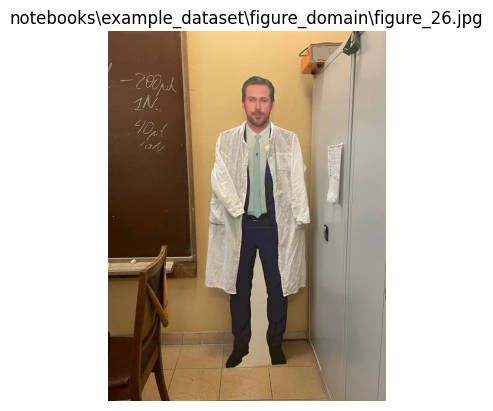

In [5]:
dataset = AttackDataset('notebooks/example_dataset')

idx = 0

print('Meta info:')
print('type(img) = ', type(dataset[idx]['img']))
print('Path = ', dataset[idx]['path2file'])
print('Filename = ', dataset[idx]['filename'])
print('is_real = ', dataset[idx]['is_real'])
print('type_attack = ', dataset[idx]['type_attack'])

show_img(dataset[idx]['path2file'], dataset[idx]['img'])

## BaseModel

In [6]:
from src.base import BaseModel

In [7]:
class RandomModel(BaseModel):
    def __init__(self, model: Any):
        super().__init__(model=model)

    def predict(self, img: Any) -> float:
        return np.random.rand()

In [8]:
model = RandomModel(model=None)
model.predict(1)

0.14766273748619785

## Подклассы от BaseTransform

In [9]:
from src import transforms

In [10]:
list_transforms = [
    transforms.PerspectiveTransform(),
    transforms.GridDropoutTransform(unit_size_range=(10, 120)),
]

In [11]:
list_type_transforms = [
    transforms.PerspectiveTransform,
    transforms.GridDropoutTransform,
]

## PipelineAttackImg

In [12]:
from src.pipeline import PipelineAttackImg

C:\Users\kobel\учёба\diploma\fas_aug_attack\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
attack_pipeline = PipelineAttackImg(
    model=model,
    list_transforms=list_transforms,
)

Probability = 0.6688549433354624
Transformed image:


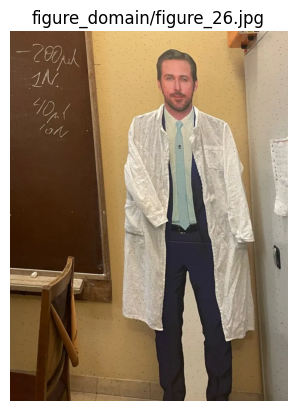

Probability = 0.7245321429636515
Transformed image:


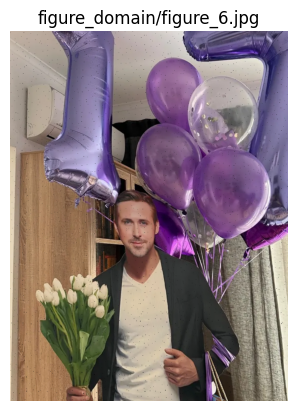

Probability = 0.3957619314469769
Transformed image:


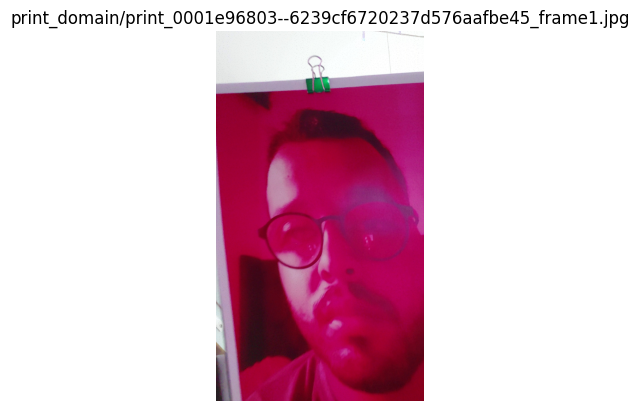

Probability = 0.40414228423635046
Transformed image:


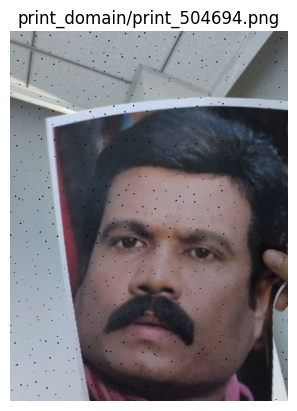

Probability = 0.9950307065199243
Transformed image:


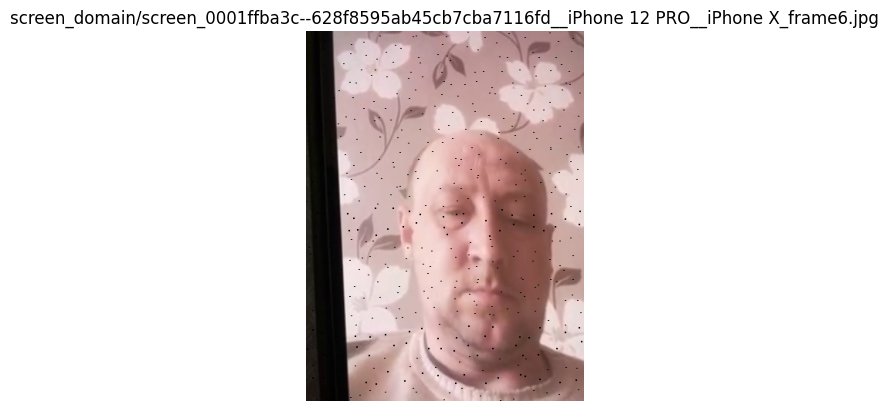

Probability = 0.9537445894324178
Transformed image:


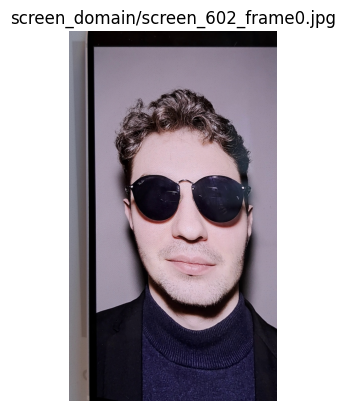

In [15]:
for i in range(len(dataset)):
    x_dict = dataset[i]
    pred_dict = attack_pipeline.attack(x_dict['img'])

    print(f'Probability = {pred_dict["score"]}')
    print('Transformed image:')
    show_img(x_dict['type_attack'] + '/' + x_dict['filename'], pred_dict['img'])

## OptunaPipelineAttackImgOptuna

In [16]:
from src.pipeline import OptunaPipelineAttackImgOptuna

In [18]:
optuna_attack_pipeline = OptunaPipelineAttackImgOptuna(
    model=model,
    list_type_transforms=list_type_transforms,
)

optuna_attack_pipeline.optimize(
    img=dataset[0]['img'],
    direction='minimize',
    study_name='testing_optuna_attack_pipeline',
    n_trials=10,
    timeout=None,
    show_progress=False,
)